In [3]:
import pandas as pd
df = pd.read_csv('uber_gachibowli_traffic.csv')
print(df.columns.tolist())
print(df.head(2))

['DateTime', 'Junction', 'Vehicles_Count', 'Weather_Condition', 'Event']
              DateTime    Junction  Vehicles_Count Weather_Condition     Event
0  2024-01-01 00:00:00  Gachibowli             159            Cloudy  No_Event
1  2024-01-01 01:00:00  Gachibowli             147             Clear  No_Event


             DateTime    Junction  Vehicles_Count Weather_Condition     Event  \
0 2024-01-01 00:00:00  Gachibowli             159            Cloudy  No_Event   
1 2024-01-01 01:00:00  Gachibowli             147             Clear  No_Event   
2 2024-01-01 02:00:00  Gachibowli             162             Clear  No_Event   
3 2024-01-01 03:00:00  Gachibowli             180             Clear  No_Event   
4 2024-01-01 04:00:00  Gachibowli             145             Clear  No_Event   

   Hour  DayOfWeek  IsWeekend  
0     0          0          0  
1     1          0          0  
2     2          0          0  
3     3          0          0  
4     4          0          0  
ARIMA Done
LSTM X shape: (1723, 24, 1)
Best Grid: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
MAE 33.91 R2 0.9523


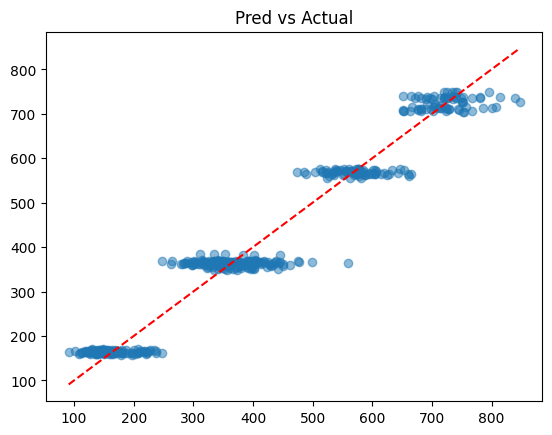

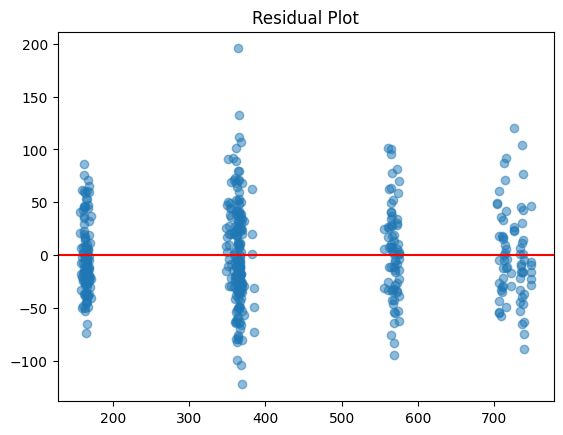

kFold MAE 33.46 +- 1.39
Time CV MAE 33.72 +- 0.68
Stacking MAE 36.02 R2 0.9449
✅ CSV Saved! Component 5 Complete!


In [4]:
# Component 5 - Data Modelling - Kappari Vaishnavi - CORRECTED
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, KFold, TimeSeriesSplit
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.arima.model import ARIMA

df = pd.read_csv('uber_gachibowli_traffic.csv')
df['DateTime'] = pd.to_datetime(df['DateTime'])
df = df.sort_values('DateTime')
df['Hour'] = df['DateTime'].dt.hour
df['DayOfWeek'] = df['DateTime'].dt.dayofweek
df['IsWeekend'] = (df['DayOfWeek']>=5).astype(int)
print(df.head())

# Target column = Vehicles_Count
TARGET = 'Vehicles_Count'

# Time-based Split 80/20
split = int(len(df)*0.8)
train, val = df[:split], df[split:]
X_train, y_train = train[['Hour','DayOfWeek','IsWeekend']], train[TARGET]
X_val, y_val = val[['Hour','DayOfWeek','IsWeekend']], val[TARGET]

# ARIMA
arima = ARIMA(y_train, order=(5,1,0)).fit()
print("ARIMA Done")

# LSTM Sequence
Xs = np.array([y_train.iloc[i:i+24].values for i in range(len(y_train)-24)]).reshape(-1,24,1)
print("LSTM X shape:", Xs.shape)

# Gradient Boosting + Grid Search
gb = GradientBoostingRegressor(random_state=42)
param_grid = {'n_estimators':[100,200],'max_depth':[3,5],'learning_rate':[0.05,0.1]}
grid = GridSearchCV(gb, param_grid, cv=3, scoring='neg_mean_absolute_error')
grid.fit(X_train, y_train)
pred = grid.predict(X_val)
print(f"Best Grid: {grid.best_params_}")
print(f"MAE {mean_absolute_error(y_val, pred):.2f} R2 {r2_score(y_val, pred):.4f}")

# Evaluation Plots
plt.figure(); plt.scatter(y_val, pred, alpha=0.5); plt.plot([y_val.min(), y_val.max()],[y_val.min(), y_val.max()],'r--'); plt.title('Pred vs Actual'); plt.show()
plt.figure(); plt.scatter(pred, y_val-pred, alpha=0.5); plt.axhline(0,color='r'); plt.title('Residual Plot'); plt.show()

# Cross Validation
kf = KFold(5, shuffle=True, random_state=42)
maes = []
for tr,te in kf.split(X_train):
    gb.fit(X_train.iloc[tr], y_train.iloc[tr])
    maes.append(mean_absolute_error(y_train.iloc[te], gb.predict(X_train.iloc[te])))
print(f"kFold MAE {np.mean(maes):.2f} +- {np.std(maes):.2f}")

tscv = TimeSeriesSplit(3)
t_maes = []
for tr,te in tscv.split(X_train):
    gb.fit(X_train.iloc[tr], y_train.iloc[tr])
    t_maes.append(mean_absolute_error(y_train.iloc[te], gb.predict(X_train.iloc[te])))
print(f"Time CV MAE {np.mean(t_maes):.2f} +- {np.std(t_maes):.2f}")

# Refinement with new features
df_r = df.copy()
df_r['Lag_1h'] = df_r[TARGET].shift(1)
df_r['Lag_24h'] = df_r[TARGET].shift(24)
df_r['Rolling_3h_Mean'] = df_r[TARGET].shift(1).rolling(3).mean()
df_r['IsPeakAM'] = ((df_r['Hour']>=9)&(df_r['Hour']<=10)).astype(int)
df_r['IsPeakPM'] = ((df_r['Hour']>=18)&(df_r['Hour']<=19)).astype(int)
df_r = df_r.dropna()

split_r = int(len(df_r)*0.8)
train_r, val_r = df_r[:split_r], df_r[split_r:]
feat = ['Hour','DayOfWeek','IsWeekend','Lag_1h','Lag_24h','Rolling_3h_Mean','IsPeakAM','IsPeakPM']
Xtr, ytr = train_r[feat], train_r[TARGET]
Xv, yv = val_r[feat], val_r[TARGET]

stack = StackingRegressor(estimators=[('gb', GradientBoostingRegressor(random_state=42)), ('rf', RandomForestRegressor(n_estimators=100, random_state=42))], final_estimator=Ridge())
stack.fit(Xtr, ytr)
print(f"Stacking MAE {mean_absolute_error(yv, stack.predict(Xv)):.2f} R2 {r2_score(yv, stack.predict(Xv)):.4f}")

# Final Output
final = pd.DataFrame({'DateTime': val_r['DateTime'], 'Actual': yv, 'Predicted': stack.predict(Xv)})
final.to_csv('Component5_Final_Predictions_Kappari_Vaishnavi.csv', index=False)
print("✅ CSV Saved! Component 5 Complete!")